In [85]:
using LinearAlgebra
using Plots

## Questão 2 )



### Letra a)

Pelo exercício 1, dado $m \geq  d + 1$, podemos garantir que $L_X$ possui posto completo, o que implica que $L_X$ é uma transformação injetiva. Ou seja, garantimos que suas inversas são inversas à esquerda. 

Sabemos que "$R_{X,d} \circ L_X = id_\mathcal{P_d}$ somente se $R_{X,d} \circ L_X(p) = p$ para todo $p \in \mathcal{P_d}$"

Pela definição, sabemos que $R_{X,d}(L_X(p)) = \argmin_{q \in \mathcal{P}_d}\|L_X(q) - L_X(p)\|^2_2$. Isso é minimizado quando $$\|L_X(q) - L_X(p)\|^2_2 = 0$$, o que acontece quando $L_X(q) = L_X(p)$. Porém, como $L_X$ é injetiva, $p = q$. Assim, para todo $p \in \mathcal{P_d}$, $R_{X,d} \circ L_X(p) = p$ provando que $R_{X,d}$ é inversa à esquerda de $L_X$.



### Letra b)

Sabemos que $m \geq d + 1$, o que implica que a matriz de $L_X$ terá dimensões $m \times (d+1)$. Seja A a matriz associada a $L_X$, o problema $R_{X,d}(L_X(p)) = p$, com $L_x(p) = b$ é por definiçaõ o problema de mínimos qudrados. Dessa forma, envolve encontrar 

$$ Ap = b \rightarrow A^TAp = A^Tb \rightarrow p = (A^TA)^{-1}A^Tb$$

Como $A$ tem posto completo, o que garantimos pelo exercício 1, então $A^TA$ também, e portanto $A^TA$ é quadrada e inversível. Assim $R_{X,d}(b) = (A^TA)^{-1}A^Tb$ é uma aplicação de uma matriz sobre um vetor, o que é uma transformação linear.

### Letra c)

Sabemos que na base canônica de $\mathcal{P_d}$, $\lbrace 1, x, x^2 \dots x^d \rbrace$, nossa matriz $L_X$ se torna a matriz de Vandermonde retangular, já que sabemos que $m \geq d + 1$.


$$ \textit{Matriz de Vandermonde (V)} :
\begin{bmatrix}
1 & x_1 & x_1^2 & \dots & x_1^d \\
1 & x_2 & x_2^2 & \dots & x_2^d \\
\vdots & \vdots & \vdots & \vdots & \vdots \\
1 & x_m & x_m^2 & \dots & x_m^d 
\end{bmatrix}
$$

Como vimos no item $b$, a solução de mínimos quadrados é $p = (A^TA)^{-1}A^Tb$. Portanto, podemos calcular $R_{X,d}$ como a pseudo-inversa de $L_x$. Assim,

$$ R_{X,d} = (V^TV)^{-1}V^T$$

é a matriz associada a $R_{X,d}$ na base canônica de $\mathcal{P}_d$. 


### Letra d )

A questão pede para escolhermos alguns valores de $m =$ #$X$ e $d$ e estudar qual o comportamento do condicionamento de $L_X$ e $R_{X,d}$ na base canônica $\mathcal{P_d}$, ou seja, $L_X$ é uma matriz de Vandermonde retangular e $R_{X,d}$ sua pseudo-inversa, quando $m$ e/ou $d$ aumentam.

Primeiramente, vamos provar que o condicionamento das matrizes associadas a $L_X$ e $R_{X,d}$ é igual. Seja A a matriz associada a $L_X$ então a matriz associada a $R_{X,d}$ é a pseudo-inversa de A. Por definição, o condicionamento de uma matriz retangular com $m \geq n$ e posto completo é definido em termos da sua pseudo-inversa, logo, igual a norma da $A$ vezes a norma da sua pseudo-inversa.

$$ \kappa (A) = \| A \| \|A^+\|$$

Seja $A = \hat{U} \hat{\Sigma} V^T$ a SVD reduzida de $A$, então a SVD reduzida de $A^+$ é $A^+A = I \rightarrow A^+\hat{U} \hat{\Sigma} V^T = I \rightarrow A^+ = V \hat{\Sigma}^{-1} \hat{U}^T$.

Portanto, o maior valor singular de $A$ é $\sigma_1$ e o menor é $\sigma_{d+1}$, e os de $A^+$ são $\frac{1}{\sigma_{d+1}}$ e $\frac{1}{\sigma_1}$.

Dessa forma, sabemos também que o condicionamento de uma matriz quando utilizado a norma 2 pode ser expresso como

$$ \kappa (A) = \frac{\sigma_{máx}}{\sigma_{mín}}$$

Logo, $\kappa (A) = \kappa (A^+) = \frac{\sigma_{1}}{\sigma_{d+1}}$.

In [86]:
function createVandermonde(vetor, d)
    Vandermonde = vetor .^ (0:d)'
    return Vandermonde
end    

function evaluate_condition(m, d)
    vetor = LinRange(-1,1,m)
    V = createVandermonde(vetor, d)
    return cond(V)
end

evaluate_condition (generic function with 1 method)

In [87]:
function plot_condition_evaluated(m, d, variate_m = true, variate_d = false, log_scale= false)
    if variate_m && !variate_d
        x = (d+1):m
        y = [evaluate_condition(i, d) for i in x]

        if log_scale
            display(plot(x, y, xlabel= "m", ylabel= "condition", title= "d fixed = $d, m ascending", yscale= :log10))
        else
            display(plot(x, y, xlabel= "m", ylabel= "condition", title= "d fixed = $d, m ascending"))
        end
        
    elseif !variate_m && variate_d
        x = 1:d
        y = [evaluate_condition(m, j) for j in x]

        if log_scale
            display(plot(x, y, label="m fixo=$m", xlabel= "d", ylabel= "condition", title= "m fixed = $m, d ascending", yscale= :log10))
        else
            display(plot(x, y, label="m fixo=$m", xlabel= "d", ylabel= "condition", title= "m fixed = $m, d ascending"))
        end
    end
end

plot_condition_evaluated (generic function with 4 methods)

Apenas $m$ aumentando

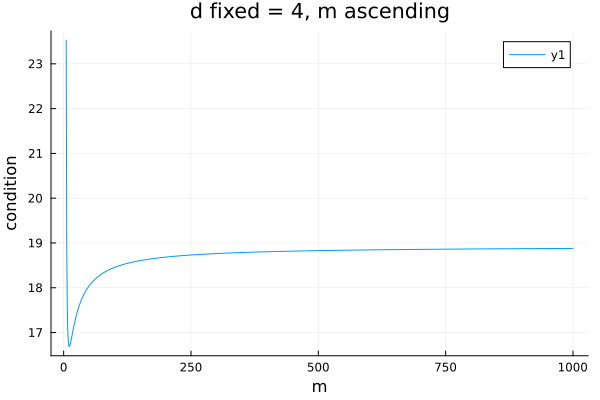

In [88]:
plot_condition_evaluated(1000, 4, true, false)


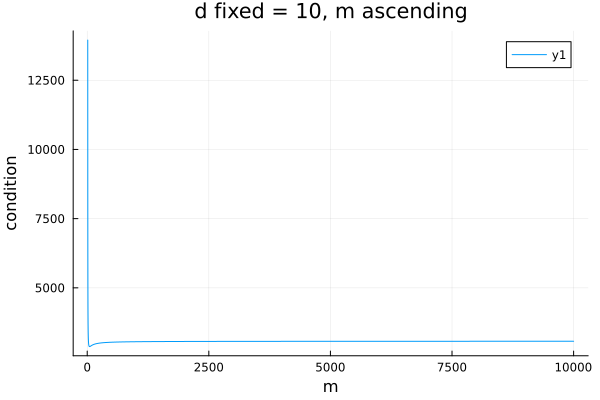

In [89]:
plot_condition_evaluated(10000, 10, true, false)

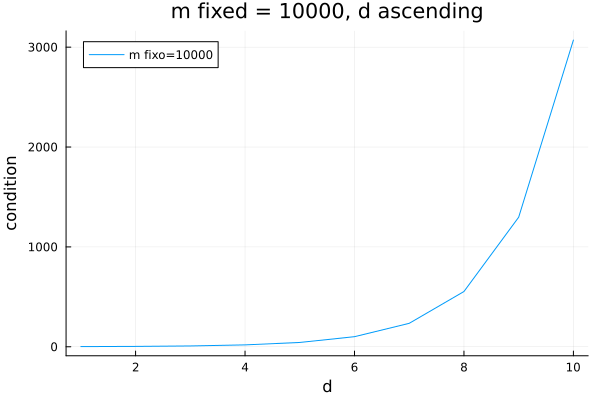

In [90]:
plot_condition_evaluated(10000, 10, false, true)


### Letra e)

#### Calculando as Matrizes

Sabemos que a matriz de Vandermonde realiza a avalização de um polinômio da base canônica em um ponto $x_i$. Trocando da base cancônica para a base dos polinômios interpoladores de Lagrange, sabemos que 

$$p_i(x_j) = \delta_{ij},  \space \space 
 \delta{ij} =\begin{cases}
                1, i=j \\
                0, i \neq j
                \end{cases}
$$

Assim, ao avaliar um polinômio que é a combinação linear dos polinômios da base em um ponto $x_j$ (linha $j$), aparecerá apenas a parte do polinômio relacionada àquela linha. Logo, $L_X$ na base de Lagrange é

$$A =
\begin{bmatrix}
I_{d+1 \times d+1} \\ 0_{m - (d+1) \times d+1}
\end{bmatrix}

\Longrightarrow 

(L_X)_{ij} = \begin{cases}
                1, i=j \\
                0, i \neq j
                \end{cases}
$$

* Essa base foi calculada com $p_i(x) = \prod_{\substack{j=0 \\ j \neq i}}^{n} \frac{x - x_j}{x_i - x_j}$, fazendo com que não tivesse lixo, diferente da interpolação utilizada para provar que $L_X$ tem posto completo.

Assim, $R_X,d$ nessa nova base tem a mesma fórmula que na base antiga $R_{X,d}(b) = (A^TA)^{-1}A^Tb$. Portanto, 

$$ (A^TA)^{-1}A^T = \begin{bmatrix}
I_{(d+1) \times (d+1)} \space \space 0_{(d+1) \times m - (d+1)}
\end{bmatrix}$$

#### Condicionamento

Sabemos que os valores singulares de uma matriz $A$ são iguais a raiz dos autovalores de $A^TA$. Dessa forma, $$A^TA = \begin{bmatrix}
I_{(d+1) \times (d+1)} \space \space 0_{(d+1) \times m - (d+1)}
\end{bmatrix}\begin{bmatrix}
I_{d+1 \times d+1} \\ 0_{m - (d+1) \times d+1}
\end{bmatrix} = \begin{bmatrix}
I_{d+1 \times d+1} 
\end{bmatrix}$$

Como seus autovalores são $1$, então os valores singulares de $A$ são também iguais a $1$ e, portanto, o condicionamento da matriz $A$

$$\kappa (A) = \kappa(A^+) = 1$$

Assim, o condicionamento de $L_X$ e $R_{X,d}$ na base dos polinômios de Lagrange é igual a $1$.

### Letra f)

#### Base Canônica
Para calcular $L_X$ na base canônica, ou seja, para calcular a matriz de Vandermonde é necessário para cada linha $d - 1$ multiplicações para encontrarmos cada entrada, assim, para as $m$ linhas, nós encontramos uma complexidade $O(md)$.

#### Base de Lagrange
Nós podemos usar do fato de que nós já conhecemos a contrução de ambas as matrizes $L_X$ e $R_{X,d}$, respectivamente:

$$\begin{bmatrix}
I_{d+1 \times d+1} \\ 0_{m - (d+1) \times d+1}
\end{bmatrix}
\space \space \space \space \space \space\space \space \space
\begin{bmatrix}
I_{(d+1) \times (d+1)} \space \space 0_{(d+1) \times m - (d+1)}
\end{bmatrix}
$$

Portanto, a complexidade para calcular ambas é $O(1)$. Assim como o condicionamento dessas matrizes é $\kappa = 1$.

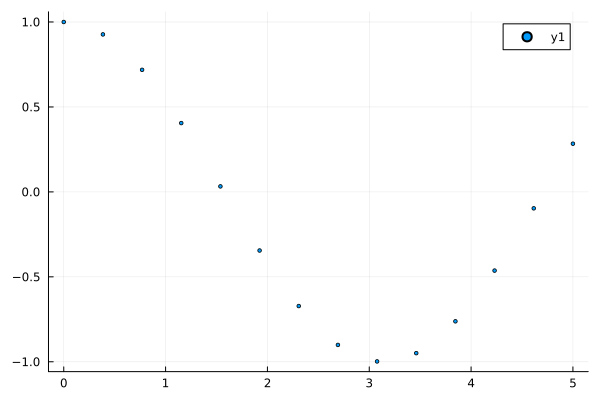

In [91]:
x = LinRange(0,5,14)
y = cos.(x)

scatter(x, y, marker= 2)

## Questão 3 )

### Letra a )

Sabemos que $R_{X_d}: \mathbb{R}^m \rightarrow \mathcal{P}_d$, $R_{X,d} \circ L_X = id_{\mathcal{P}_d}$, o que significa que para todo $p \in \mathcal{P}_d$ existe um vetor $b = L_X(p) \in \mathbb{R}^m$ tal que $R_{X,d}(b) = p$. Portanto, $R_{X,d}$ é sobrejetora e $Im(R_{X,d}) = \mathcal{P}_d$, o que implica que o posto de $R_{X,d}$ é $dim(Im(R_{X,d})) = d+1$.

Sabemos também que $L_Y$ tem posto completo e, logo, seu posto é $\min \lbrace n, d+ 1 \rbrace$

Além disso, sabemos que a transformação $(L_Y \circ R_{X,d})(b)$ é definida como $LY(R_{X,d}(b))$, e, portanto, a entrada de $L_Y$ é a saída de $R_{X,d}$, o que implica que quem vai determinar o posto da transformação é $L_Y$. Logo, o posto da transformação é $\min \lbrace n, d+ 1 \rbrace$.



### Letra b )



### Letra c )

Vamos voltar a definição do funcional de avaliação, quando restrito ao $\mathcal{P}_d$, 

$$ L_X: \mathbb{R}^m \rightarrow \mathcal{P}_d, \space \space \space \space L_X(p) = ( p(x_1) , \dots , p(x_m))$$

Dessa forma, ao tomarmos $b \in \mathbb{R}^m$ e aplicarmos $R_{X,d}(b) = p$, essa transformação nos retorna o melhor polinômio $p$ que nos retorna $p(x_i) = b_i$. Ao aplicarmos, $L_Y$ sobre o nosso polinômio resultante $p$, então nós obtemos $L_Y(p) = (p(y_1), \dots , p(y_n))$. Ou seja, nós avaliamos os valores de $Y$ no polinômio $p$ no mesmo intervalo conhecido $[-1,1]$. Ou seja, nós interpolamos $Y$ no polinômio $p$.

### Letra d )

In [92]:
function createLagrange(X, Y, d)
    nodes = X[1:d+1]
    n = length(Y)
    L = zeros(n, d+1)

    for i in 1:(d+1)
        denominador = prod((nodes[i] - nodes[k]) for k in 1:(d+1) if k != i)
        for j in 1:n
            numerador = prod((Y[j] - nodes[k]) for k in 1:(d+1) if k != i)
            L[j, i] = numerador / denominador
        end
    end
    return L
end

createLagrange (generic function with 2 methods)

In [97]:
function evaluate(m, n, d)
    X = LinRange(-1, 1, m)
    Y = LinRange(-1, 1, n)

    L = createLagrange(X, Y ,d) * pinv(createLagrange(X, X ,d))
    C = createVandermonde(Y,d) * pinv(createVandermonde(X,d))
    
    print(L)
    print(C)
end

evaluate (generic function with 2 methods)

In [98]:
evaluate(10,30,5)

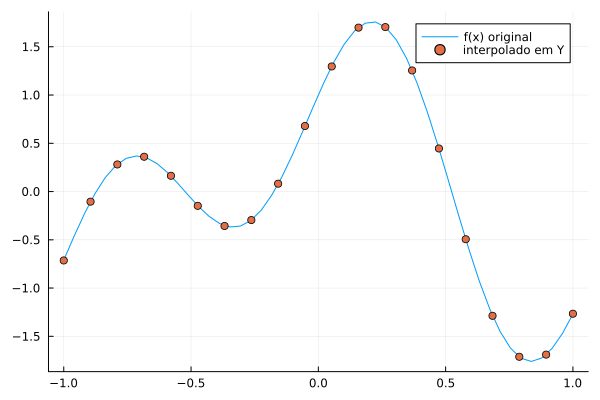

In [95]:
X = LinRange(-1, 1, 50)
Y = LinRange(-1, 1, 20)
t = cos.(3 .* X) .+ sin.(6 .* X)

y_prev = createLagrange(X, Y, 9) * pinv(createLagrange(X, X, 9)) * t

plot(X, t, label="f(x) original")
scatter!(Y, y_prev, label="interpolado em Y")